# 03 — Griegas y Volatilidad Implícita

**Módulo 3** del pipeline de valoración de opciones.

Este notebook:
1. Calcula Delta, Gamma desde la malla numérica (diferencias centrales en S)
2. Calcula Theta vía diferencia hacia atrás en el tiempo (ver nota de diseño abajo)
3. Calcula Vega, Rho vía perturbación paramétrica (diferencias centrales)
4. Invierte Black-Scholes con Newton-Raphson para obtener la volatilidad implícita
5. Compara σ histórica (MLE, notebook `01`) vs σ implícita (mercado)

Reutiliza el objeto `CrankNicolson` ya resuelto en `02_convergencia_crank_nicolson.ipynb`.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import sys, os
sys.path.append(os.path.abspath('..'))

import config
from src.resultados_io import cargar_pde, cargar_griegas, cargar_newton_raphson, cargar_volatilidad

plt.rcParams["figure.figsize"] = (10, 5)

## Parámetros del contrato (mismos que notebook 02)

In [ ]:
pde = cargar_pde()
S0, K, T, r, sigma = pde["S0"], pde["K"], pde["T"], pde["r"], pde["sigma"]
TIPO = pde["tipo"]

print(f"S0    = {S0:.2f}")
print(f"K     = {K:.2f}")
print(f"sigma (MLE) = {sigma:.4f}")
print(f"Precio Crank-Nicolson: {pde['precio_cn']:.4f}")

S0    = 194.83
K     = 195.00
sigma (MLE) = 0.4776
Precio Crank-Nicolson: 29.2958


## Delta y Gamma

Diferencias centrales en la dimensión espacial $S$, $\mathcal{O}(\Delta S^2)$:

$$\Delta_i = \frac{V_{i+1}-V_{i-1}}{2\,\Delta S} \qquad
\Gamma_i = \frac{V_{i+1}-2V_i+V_{i-1}}{(\Delta S)^2}$$

Válidas sin restricción porque todos los nodos vecinos en $S$ existen
simultáneamente en la malla ya resuelta.

In [3]:
griegas = cargar_griegas()

print(f"Delta en S0 (interpolado): {griegas['delta_S0']:.6f}")
print(f"Gamma en S0 (interpolado): {griegas['gamma_S0']:.6f}")

Delta en S0 (interpolado): 0.598309
Gamma en S0 (interpolado): 0.005671


## Perfil de Delta y Gamma en función de S

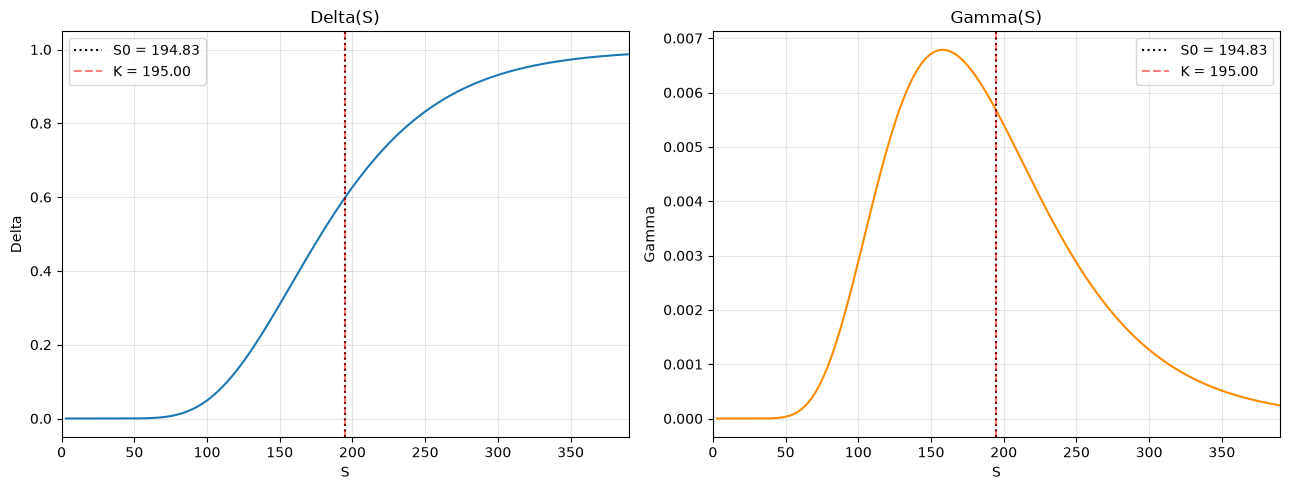

In [4]:
malla_S = griegas["malla_S"]
delta_malla = griegas["delta_malla"]
gamma_malla = griegas["gamma_malla"]

# malla_S tiene N+1 nodos; delta/gamma solo están definidos en los N-1
# nodos interiores (bordes en NaN por construcción de diferencias centrales)
S_validos = malla_S[1:-1]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].plot(S_validos, delta_malla[1:-1], linewidth=1.5)
axes[0].axvline(S0, color="black", linestyle=":", label=f"S0 = {S0:.2f}")
axes[0].axvline(K, color="red", linestyle="--", alpha=0.5, label=f"K = {K:.2f}")
axes[0].set_title("Delta(S)")
axes[0].set_xlabel("S")
axes[0].set_ylabel("Delta")
axes[0].set_xlim(0, K * 2)
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(S_validos, gamma_malla[1:-1], linewidth=1.5, color="darkorange")
axes[1].axvline(S0, color="black", linestyle=":", label=f"S0 = {S0:.2f}")
axes[1].axvline(K, color="red", linestyle="--", alpha=0.5, label=f"K = {K:.2f}")
axes[1].set_title("Gamma(S)")
axes[1].set_xlabel("S")
axes[1].set_ylabel("Gamma")
axes[1].set_xlim(0, K * 2)
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## Theta

$$\Theta \approx \frac{V(t=\Delta t) - V(t=0)}{\Delta t}, \qquad \mathcal{O}(\Delta t)$$

**Nota de diseño:** se usa diferencia hacia atrás, no central. $t=0$ es la
frontera del dominio temporal de la malla — Crank-Nicolson resuelve desde $T$
hacia atrás y se detiene en $t=0$, así que no existe un punto $V(t=-\Delta t)$
dentro de la misma malla. Obtenerlo requeriría resolver un problema distinto
(con $S_0$ y $\sigma$ de otro día), lo cual mezclaría el efecto puro del paso
del tiempo con cambios no controlados en los demás parámetros — efectos que
Vega y Rho ya aíslan por separado. Por eso Theta queda en $\mathcal{O}(\Delta t)$
mientras Delta/Gamma logran $\mathcal{O}(\Delta S^2)$.

In [5]:
theta = griegas["theta"]
print(f"Theta: {theta:.6f}")
print(f"(interpretación: la opción pierde ~{abs(theta):.4f} de valor por unidad de tiempo, "
      f"manteniendo todo lo demás constante)")

Theta: -28.923197
(interpretación: la opción pierde ~28.9232 de valor por unidad de tiempo, manteniendo todo lo demás constante)


## Vega y Rho

Derivadas respecto a parámetros del modelo ($\sigma$, $r$), no de la malla.
Se obtienen resolviendo Crank-Nicolson dos veces más con perturbación
pequeña $\Delta$, vía diferencia central $\mathcal{O}(\Delta^2)$:

$$\nu = \frac{V(\sigma+\Delta\sigma) - V(\sigma-\Delta\sigma)}{2\Delta\sigma}
\qquad
\rho = \frac{V(r+\Delta r) - V(r-\Delta r)}{2\Delta r}$$

In [6]:
vega = griegas["vega"]
rho  = griegas["rho"]

print(f"Vega: {vega:.6f}  (cambio en precio por unidad de cambio en sigma)")
print(f"Rho : {rho:.6f}  (cambio en precio por unidad de cambio en r)")

Vega: 55.205020  (cambio en precio por unidad de cambio en sigma)
Rho : 46.873764  (cambio en precio por unidad de cambio en r)


## Sensibilidad de Vega al tamaño de la perturbación $\Delta\sigma$

Trade-off clásico de diferencias finitas: $\Delta$ muy grande introduce error
de truncamiento, $\Delta$ muy pequeño introduce error de redondeo de punto
flotante. El valor óptimo suele estar en un punto intermedio.

<>:22: SyntaxWarning: invalid escape sequence '\D'
<>:22: SyntaxWarning: invalid escape sequence '\D'
C:\Users\USUARIO\AppData\Local\Temp\ipykernel_18668\3983364073.py:22: SyntaxWarning: invalid escape sequence '\D'
  plt.xlabel("$\Delta\sigma$")


d_sigma = 1e-01   vega = 55.185491
d_sigma = 1e-02   vega = 55.204828
d_sigma = 1e-03   vega = 55.205018
d_sigma = 1e-04   vega = 55.205020
d_sigma = 1e-05   vega = 55.205020
d_sigma = 1e-06   vega = 55.205020


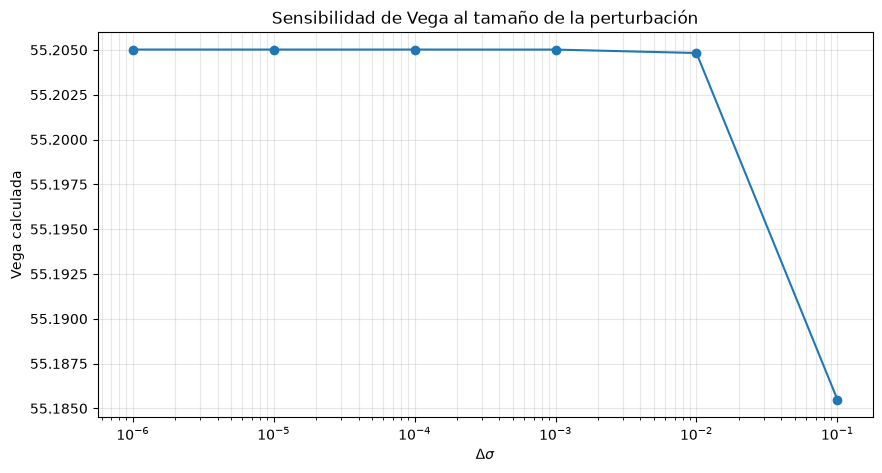

In [ ]:
from src.pde_solver import CrankNicolson
from src.griegas import Griegas

solver = CrankNicolson(S0, K, T, r, sigma, tipo=TIPO)
solver.resolver()
g_local = Griegas(solver)

deltas_sigma = [1e-1, 1e-2, 1e-3, 1e-4, 1e-5, 1e-6]
vegas_por_delta = []

for d in deltas_sigma:
    v = g_local.calcular_vega(d_sigma=d)
    vegas_por_delta.append(v)
    print(f"d_sigma = {d:.0e}   vega = {v:.6f}")

plt.semilogx(deltas_sigma, vegas_por_delta, "o-")
plt.xlabel("$\Delta\sigma$")
plt.ylabel("Vega calculada")
plt.title("Sensibilidad de Vega al tamaño de la perturbación")
plt.grid(alpha=0.3, which="both")
plt.show()

## Resumen del perfil de riesgo completo

In [8]:
print(f"{'Griega':<10} {'Valor':>12}")
print("-" * 24)
print(f"{'delta':<10} {griegas['delta_S0']:>12.6f}")
print(f"{'gamma':<10} {griegas['gamma_S0']:>12.6f}")
print(f"{'theta':<10} {griegas['theta']:>12.6f}")
print(f"{'vega':<10} {griegas['vega']:>12.6f}")
print(f"{'rho':<10} {griegas['rho']:>12.6f}")

Griega            Valor
------------------------
delta          0.598309
gamma          0.005671
theta        -28.923197
vega          55.205020
rho           46.873764


## Volatilidad Implícita — Newton-Raphson

Dado un precio de mercado observado $C_{\text{mercado}}$, se busca el $\sigma$
que satisface $BS(\sigma) = C_{\text{mercado}}$:

$$\sigma_{n+1} = \sigma_n - \frac{BS(\sigma_n)-C_{\text{mercado}}}{\nu(\sigma_n)}$$

Usa la Vega cerrada de Black-Scholes (no la Vega numérica vía Crank-Nicolson)
para evitar resolver CN repetidamente en cada iteración. Converge
cuadráticamente.

In [ ]:
vol = cargar_volatilidad()
historial = cargar_newton_raphson()

print(f"C_mercado usado : {vol['C_mercado']:.4f}")
print()
print(historial.to_string(index=False))
print(f"\nsigma implicita convergida: {vol['sigma_implicita']:.6f}")

C_mercado usado : 25.7750

 iter    sigma         error
    1 0.477641  3.515537e+00
    2 0.413971 -5.373580e-03
    3 0.414068 -9.873325e-09

sigma implicita convergida: 0.414068


## σ histórica (MLE) vs σ implícita (Newton-Raphson)

In [10]:
sigma_historica = vol["sigma_historica"]
sigma_implicita = vol["sigma_implicita"]
diferencia = sigma_implicita - sigma_historica

print(f"{'Parámetro':<20} {'Valor':>10}")
print("-" * 32)
print(f"{'sigma histórica':<20} {sigma_historica:>9.4f}")
print(f"{'sigma implícita':<20} {sigma_implicita:>9.4f}")
print(f"{'diferencia':<20} {diferencia:>+9.4f}")

if diferencia > 0:
    print("\n-> El mercado anticipa MÁS volatilidad que la histórica reciente (opción 'cara' relativo al pasado)")
elif diferencia < 0:
    print("\n-> El mercado anticipa MENOS volatilidad que la histórica reciente (opción 'barata' relativo al pasado)")
else:
    print("\n-> El mercado coincide exactamente con la volatilidad histórica")

Parámetro                 Valor
--------------------------------
sigma histórica         0.4776
sigma implícita         0.4141
diferencia             -0.0636

-> El mercado anticipa MENOS volatilidad que la histórica reciente (opción 'barata' relativo al pasado)


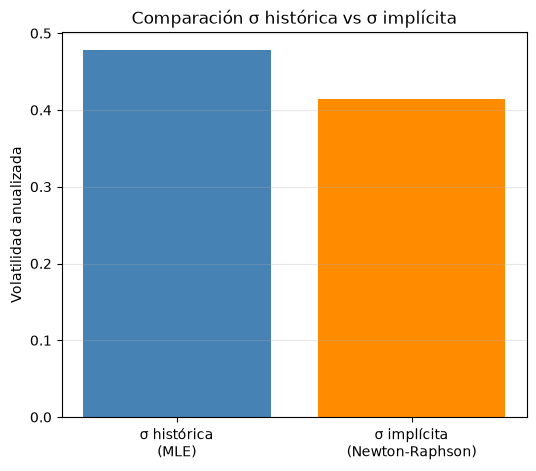

In [11]:
fig, ax = plt.subplots(figsize=(6, 5))
ax.bar(["σ histórica\n(MLE)", "σ implícita\n(Newton-Raphson)"],
       [sigma_historica, sigma_implicita],
       color=["steelblue", "darkorange"])
ax.set_ylabel("Volatilidad anualizada")
ax.set_title("Comparación σ histórica vs σ implícita")
ax.grid(alpha=0.3, axis="y")
plt.show()

## Resumen final — perfil de riesgo completo del contrato

| Griega | Significado |
|---|---|
| Delta | sensibilidad del precio a $S$ |
| Gamma | convexidad del precio respecto a $S$ |
| Theta | decaimiento del valor por el paso del tiempo |
| Vega | sensibilidad del precio a $\sigma$ |
| Rho | sensibilidad del precio a $r$ |
| σ implícita | volatilidad que el mercado descuenta hacia adelante |

In [12]:
resumen_final = {
    "delta": griegas["delta_S0"],
    "gamma": griegas["gamma_S0"],
    "theta": griegas["theta"],
    "vega": griegas["vega"],
    "rho": griegas["rho"],
    "sigma_historica": sigma_historica,
    "sigma_implicita": sigma_implicita,
}

for k, v in resumen_final.items():
    print(f"{k:<18}: {v:.6f}")

delta             : 0.598309
gamma             : 0.005671
theta             : -28.923197
vega              : 55.205020
rho               : 46.873764
sigma_historica   : 0.477641
sigma_implicita   : 0.414068
